#### Task 2: Data Acquisition & Initial Visualization

You may use the provided USGS streamflow datasets or a time-series dataset of your own choosing, provided it has at least daily resolution.

**Load Data:** Read the raw data into a Pandas DataFrame from your  data/ folder.

**Process the data:** Subset the data so that all of the data is overlapping and is 6 years in length.

**Exploratory Data Analysis (EDA):** Create an initial time-series plot of the data, ensure the plot has a title, axes labels, legend. etc. Create a figure with four subplots to visualize the data.

**Compare and Contrast:** How do the different streams compare (timing, magnitude, other)?

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#load data
blackfork = pd.read_csv('data/09217900_1980_2020.csv')
greenriver = pd.read_csv('data/09234500_1980_2020.csv')

greenriver.head()


,Datetime,USGS_flow,variable,USGS_ID,measurement_unit,qualifiers,series
0,1986-10-01,2139.7144,streamflow,9234500,ft3/s,"['A', '[91]']",0
1,1986-10-02,2295.4167,streamflow,9234500,ft3/s,"['A', '[91]']",0
2,1986-10-03,2061.4792,streamflow,9234500,ft3/s,"['A', '[91]']",0
3,1986-10-04,2219.3750,streamflow,9234500,ft3/s,"['A', '[91]']",0
4,1986-10-05,1778.7500,streamflow,9234500,ft3/s,"['A', '[91]']",0


In [39]:
# what years does the data cover?
print("Blacks Fork data covers years:", blackfork['Datetime'].min(), "to", blackfork['Datetime'].max())
print("Green River data covers years:", greenriver['Datetime'].min(), "to", greenriver['Datetime'].max())

# 6 years of data = let's subset 2014-2019
blackfork_subset = blackfork[(blackfork['Datetime'] >= '2014-01-01') & (blackfork['Datetime'] <= '2019-12-31')]
greenriver_subset = greenriver[(greenriver['Datetime'] >= '2014-01-01') & (greenriver['Datetime'] <= '2019-12-31')]

print(' ')

#check for NAs
print("Blacks Fork NAs after subset:", blackfork_subset['USGS_flow'].isna().sum())
print("Green River NAs after subset:", greenriver_subset['USGS_flow'].isna().sum())

print(' ')

#check for weird values
print('Blacks Fork after subset:\n', blackfork_subset['USGS_flow'].describe(), '\n')
print('Green River after subset:\n', greenriver_subset['USGS_flow'].describe())


Blacks Fork data covers years: 1992-10-29 to 2020-09-29
Green River data covers years: 1986-10-01 to 2020-09-29
 
Blacks Fork NAs after subset: 358
Green River NAs after subset: 0
 
Blacks Fork after subset:
 count    1833.000000
mean      198.014359
std       305.952409
min         2.742917
25%        34.416668
50%        70.145836
75%       223.031250
max      2583.444300
Name: USGS_flow, dtype: float64 

Green River after subset:
 count    2191.000000
mean     2369.497845
std      1845.095997
min       776.104200
25%      1615.104100
50%      1918.229100
75%      2225.317750
max      9174.062500
Name: USGS_flow, dtype: float64


In [38]:
#check the Blacks Fork high values to make sure they make sense
#get values from the date column of top 10 high flows and sort them by date
top_10_high_flows = blackfork_subset['USGS_flow'].nlargest(10)
top_10_high_flow_dates = blackfork_subset.loc[top_10_high_flows.index, 'Datetime']
print("Dates of top 10 high flows:\n", top_10_high_flow_dates.sort_values())

Dates of top 10 high flows:
 8624    2016-06-09
8625    2016-06-10
9717    2019-06-07
9718    2019-06-08
9723    2019-06-13
9724    2019-06-14
9725    2019-06-15
9726    2019-06-16
9727    2019-06-17
9730    2019-06-20
Name: Datetime, dtype: object


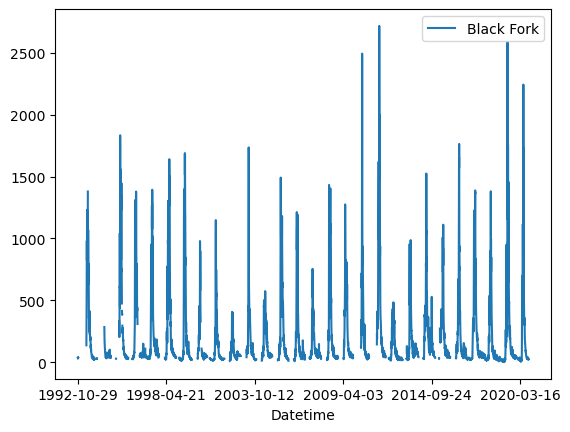

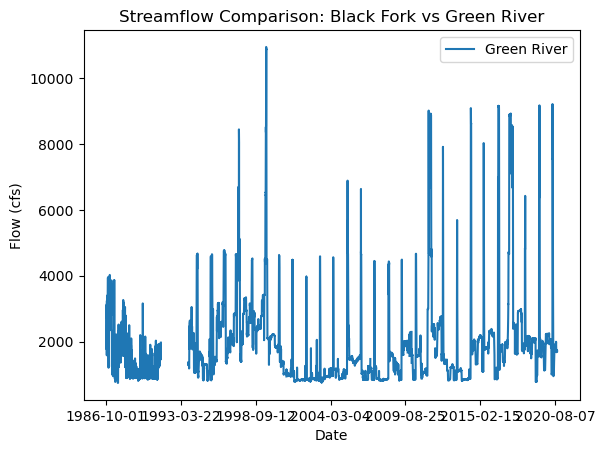

In [16]:
#create plot
blackfork.plot(x='Datetime', y='USGS_flow', label='Black Fork')
greenriver.plot(x='Datetime', y='USGS_flow', label='Green River')
plt.xlabel('Date')
plt.ylabel('Flow (cfs)') 
plt.title('Streamflow Comparison: Black Fork vs Green River')
plt.legend()
plt.show()